# Cuaternión → ángulos de Euler vs tiempo

Lee `27_07/cuat.csv` (cuaternión de orientación estimado, `estOrientQuaternion`, a 50 Hz),
lo convierte a ángulos de Euler (**roll**, **pitch**, **yaw**) y grafica su comportamiento en el tiempo.

El cuaternión viene como `[w, x, y, z]` (columnas `[0-0]..[0-3]`). El `Time` está en nanosegundos Unix.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv_path = r'27_07/cuat.csv'

# El archivo tiene metadatos arriba; los datos empiezan tras 'DATA_START'.
# Buscamos la fila cuyo encabezado empieza con 'Time,' y la usamos como header.
with open(csv_path, 'r') as f:
    lines = f.readlines()
header_row = next(i for i, ln in enumerate(lines) if ln.startswith('Time,'))

df = pd.read_csv(csv_path, skiprows=header_row)
# Renombramos las columnas del cuaternion a algo corto
qcols = [c for c in df.columns if 'estOrientQuaternion[' in c]
df = df.rename(columns={
    'Time': 'time_ns',
    qcols[0]: 'qw', qcols[1]: 'qx', qcols[2]: 'qy', qcols[3]: 'qz',
})
valid_col = [c for c in df.columns if c.endswith(':valid')]
if valid_col:
    df = df.rename(columns={valid_col[0]: 'valid'})

# Tiempo relativo en segundos desde la primera muestra
df['t'] = (df['time_ns'] - df['time_ns'].iloc[0]) / 1e9
print(f"{len(df)} muestras | duracion {df['t'].iloc[-1]:.1f} s | fs ~ {1/df['t'].diff().median():.1f} Hz")
df[['t', 'qw', 'qx', 'qy', 'qz']].head()

650 muestras | duracion 13.0 s | fs ~ 50.0 Hz


,t,qw,qx,qy,qz
0,0.000000,0.998808,-0.047485,0.006686,0.009136
1,0.019923,0.998807,-0.047498,0.006680,0.009137
2,0.039943,0.998807,-0.047501,0.006686,0.009138
3,0.059975,0.998807,-0.047497,0.006688,0.009140
4,0.079971,0.998807,-0.047500,0.006692,0.009143


In [2]:
def quat_to_euler(qw, qx, qy, qz):
    """Cuaternion [w,x,y,z] -> (roll, pitch, yaw) en grados. Convencion ZYX (Tait-Bryan)."""
    qw, qx, qy, qz = map(np.asarray, (qw, qx, qy, qz))
    # Normalizar por seguridad
    n = np.sqrt(qw**2 + qx**2 + qy**2 + qz**2)
    qw, qx, qy, qz = qw/n, qx/n, qy/n, qz/n

    # Roll (rotacion en X)
    roll = np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))
    # Pitch (rotacion en Y), con clamp para evitar NaN en gimbal lock
    sinp = 2*(qw*qy - qz*qx)
    pitch = np.arcsin(np.clip(sinp, -1.0, 1.0))
    # Yaw (rotacion en Z)
    yaw = np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))

    return np.degrees(roll), np.degrees(pitch), np.degrees(yaw)

df['roll'], df['pitch'], df['yaw'] = quat_to_euler(df['qw'], df['qx'], df['qy'], df['qz'])
df[['t', 'roll', 'pitch', 'yaw']].describe()

,t,roll,pitch,yaw
count,650.000000,650.000000,650.000000,650.000000
mean,6.489520,-4.022433,1.054697,-28.616890
std,3.755661,1.673169,0.443132,31.729683
min,0.000000,-5.622506,-0.078029,-86.154153
25%,3.244802,-5.437426,0.785842,-54.658724
50%,6.489782,-4.307066,0.975301,-12.128195
75%,9.734597,-3.487691,1.394121,-0.158438
max,12.979540,0.111282,2.050109,3.422635


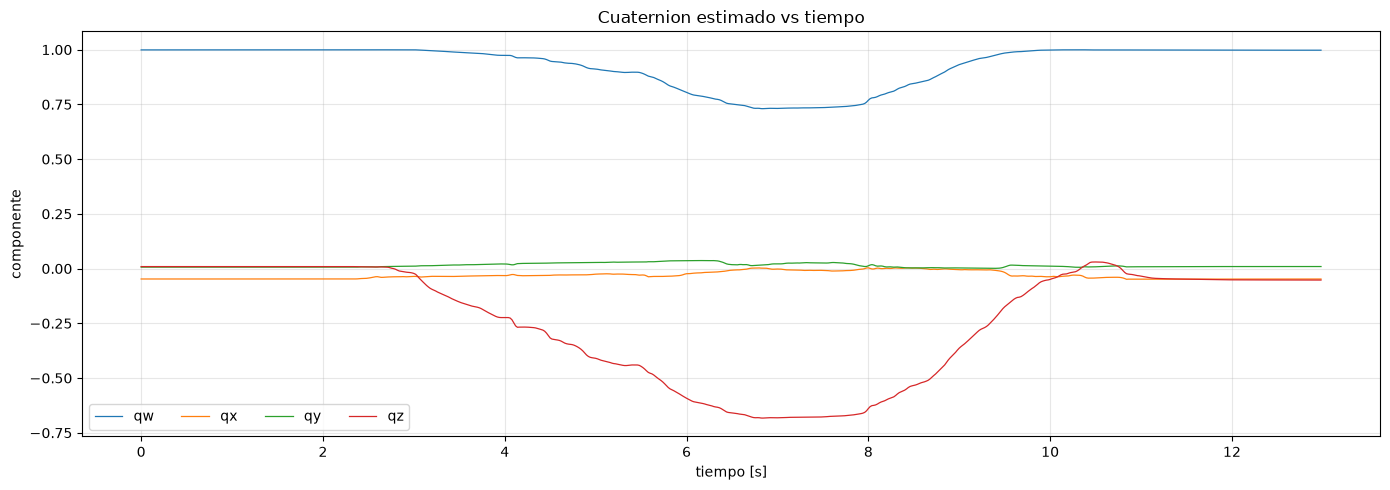

In [3]:
# Componentes del cuaternion vs tiempo
fig, ax = plt.subplots(figsize=(14, 5))
for c, lab in zip(['qw', 'qx', 'qy', 'qz'], ['w', 'x', 'y', 'z']):
    ax.plot(df['t'], df[c], label=f'q{lab}', linewidth=0.9)
ax.set_xlabel('tiempo [s]')
ax.set_ylabel('componente')
ax.set_title('Cuaternion estimado vs tiempo')
ax.legend(ncol=4)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

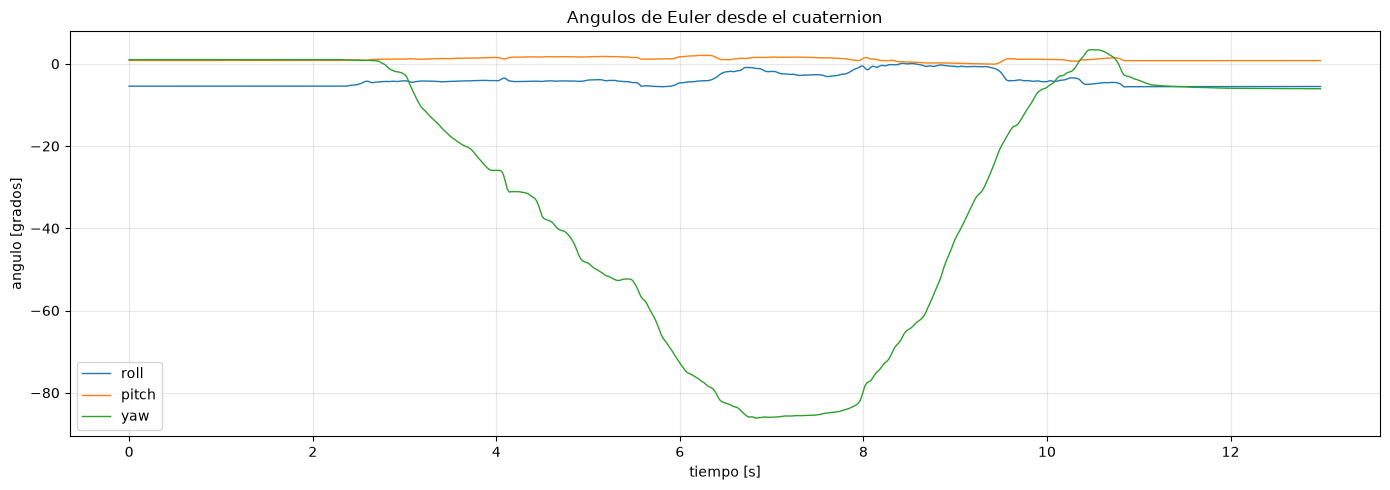

In [4]:
# Angulos de Euler (roll, pitch, yaw) juntos vs tiempo
fig, ax = plt.subplots(figsize=(14, 5))
for c, col in zip(['roll', 'pitch', 'yaw'], ['tab:blue', 'tab:orange', 'tab:green']):
    ax.plot(df['t'], df[c], label=c, linewidth=1.0, color=col)
ax.set_xlabel('tiempo [s]')
ax.set_ylabel('angulo [grados]')
ax.set_title('Angulos de Euler desde el cuaternion')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

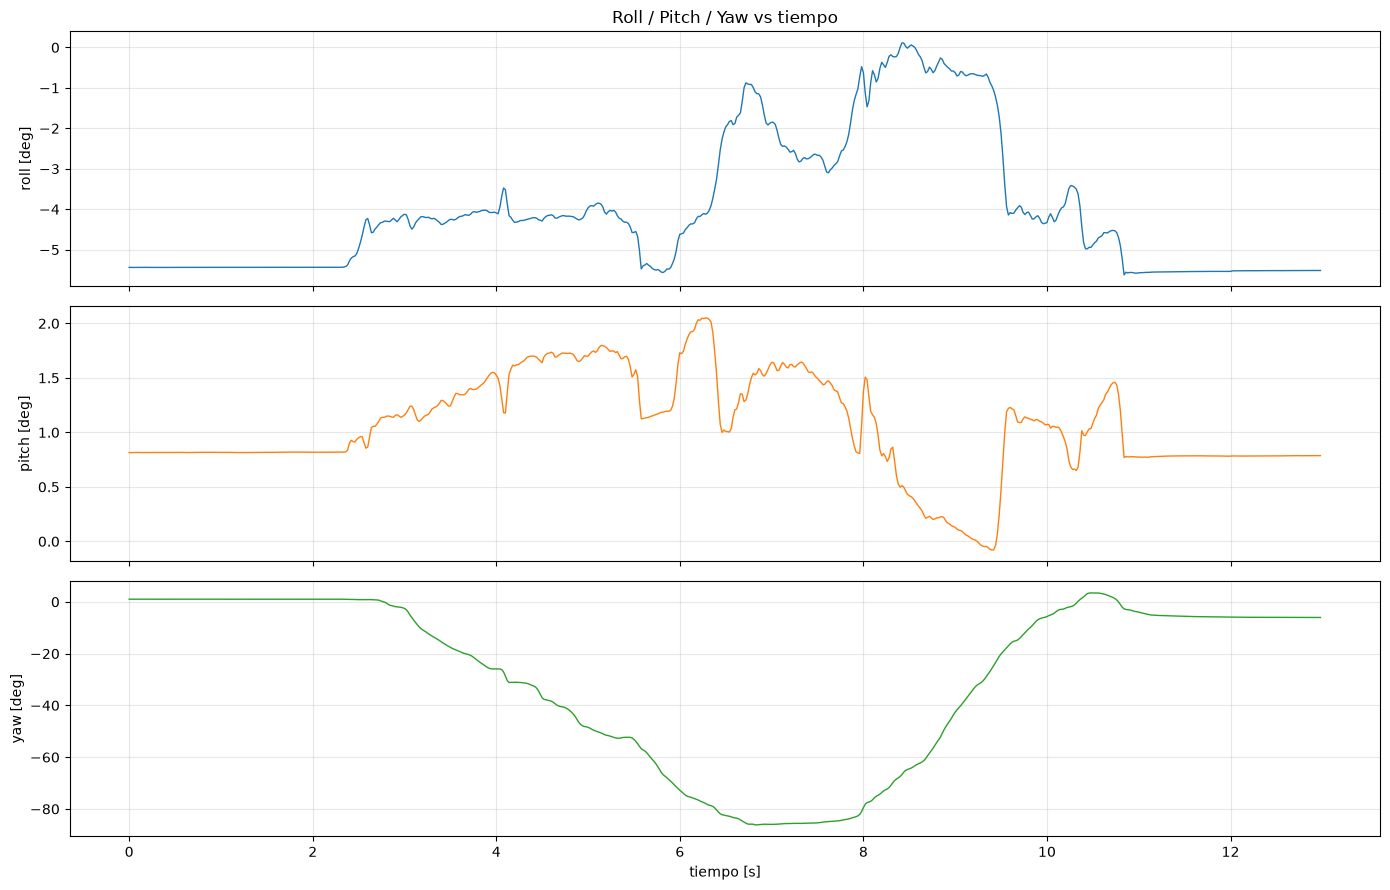

In [5]:
# Cada angulo en su propio eje (distinto rango dinamico)
cols = ['roll', 'pitch', 'yaw']
colors = ['tab:blue', 'tab:orange', 'tab:green']
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, c, col in zip(axes, cols, colors):
    ax.plot(df['t'], df[c], color=col, linewidth=1.0)
    ax.set_ylabel(f'{c} [deg]')
    ax.grid(True, alpha=0.3)
axes[0].set_title('Roll / Pitch / Yaw vs tiempo')
axes[-1].set_xlabel('tiempo [s]')
plt.tight_layout()
plt.show()